# 1. Data Loading
---
This notebook is intended to be run both locally and on kaggle. Therefore, it needs accomodates the different data sources when loading the csvs. Before handling the data, imports will all be coalesced into a specified subsection.



## 1.1 Imports


In [ ]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


## 1.2 Data Loading

In [2]:
# 1. Automatically detect the environment
IS_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

if IS_KAGGLE:
    # Settings optimized for Kaggle's NVIDIA GPUs
    TREE_METHOD = "hist"  # XGBoost
    DEVICE_TYPE = "gpu"  # LightGBM (Kaggle uses OpenCL 'gpu', not 'cuda')
    CAT_TASK_TYPE = "GPU"  # CatBoost
    print("Environment: Kaggle (NVIDIA GPU Enabled)")
else:
    # Settings optimized for the local environment
    TREE_METHOD = "hist"  # XGBoost (Uses Metal/MPS natively via hist)
    DEVICE_TYPE = "cpu"  # LightGBM (Standard Mac wheels lack GPU support)
    CAT_TASK_TYPE = "CPU"  # CatBoost (Mac GPU support is experimental; CPU is faster)
    print("Environment: Local Mac (CPU fallback for LightGBM/CatBoost)")

Environment: Local Mac (CPU fallback for LightGBM/CatBoost)


In [3]:
def load_data():
    """
    try to load the data from the local directory, if not found, load it from the Kaggle dataset.
    Output the three dataframes: train, test, and submission.
    """
    train_file_dir_name = "/train.csv"
    sample_submission_file_dir_name = "/sample_submission.csv"
    test_file_dir_name = "/test.csv"

    if IS_KAGGLE:
        # check if the data files are in kaggle direcotry
        # /kaggle/input/competitions/playground-series-s6e9
        kaggle_input_dir = "/kaggle/input/competitions/"
        competition_name = os.listdir(kaggle_input_dir)

        print("Trying to load data from kaggle input directory...")
        data_dir = "/kaggle/input/competitions/playground-series-s6e9/"
        train = pd.read_csv(
            kaggle_input_dir + competition_name[-1] + train_file_dir_name
        )
        test = pd.read_csv(kaggle_input_dir + competition_name[-1] + test_file_dir_name)
        submission = pd.read_csv(
            kaggle_input_dir + competition_name[-1] + sample_submission_file_dir_name
        )
        print("Data loaded successfully from kaggle input directory.")
    else:
        print("Trying to load data from local directory...")
        # Load data from local directory
        data_dir = os.getcwd() + "/data"
        train = pd.read_csv(data_dir + train_file_dir_name)
        test = pd.read_csv(data_dir + test_file_dir_name)
        submission = pd.read_csv(data_dir + sample_submission_file_dir_name)
        print("Data loaded successfully from local directory.")

    return train, test, submission

In [4]:
train_df, test_df, submission_df = load_data()

Trying to load data from local directory...
Data loaded successfully from local directory.


# 2. Data exploration
---
Having organised the data into dataframes that can be explored and prepared for preprocessing, the necessary quality checks can be done. In this section, we will explore the data for missing values, extreme values and mislabelled data types. 

## 2.1 Check for missing values/null values

In [5]:
def check_missing_values(df):
    """
    Check for missing values in the dataframe and print the count of missing values for each column.
    """
    temp_df = df.copy()
    # check if the dataframe is empty
    if temp_df.empty:
        print("The dataframe is empty. No missing values to check.")
        return
    # check that the dataframe has missing values
    if temp_df.isnull().sum().sum() == 0:
        print("The dataframe has no missing values.")
        return
    # Iterate through each column and check the number of missing values
    for column in temp_df.columns:
        missing_count = temp_df[column].isnull().sum()
        if missing_count > 0:
            # print column name
            # number of missing values againts total number of rows in the column
            total_rows = temp_df.shape[0]
            print(
                f"{column:<25}"
                f"Missing Values: {missing_count:<10}"
                f"Total Rows: {total_rows:<10}"
                f"Percentage Missing: {missing_count / total_rows * 100:.2f}%"
            )

In [6]:
check_missing_values(train_df)


The dataframe has no missing values.


In [7]:
check_missing_values(test_df)

The dataframe has no missing values.


In [8]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str    
 13  Range_Anxi

## 2.2 Class imbalance check

In [13]:
def check_class_imbalance(df):
    """
    Check for class imbalance.
    Plots distribution of target variables.
    target column is assumed to always be Will_Buy_EV  as from competition details.

    Input-
    df: pandas dataframe

    Output-
    None

    """

    # check if the dataframe is empty
    if df.empty:
        print("The dataframe is empty. No class imbalance to check.")
        return

    # check if the target column exists
    if "Will_Buy_EV" not in df.columns:
        print("The target column 'Will_Buy_EV' does not exist in the dataframe.")
        return

    # check if the target column has more than one class
    if df["Will_Buy_EV"].nunique() <= 1:
        print(
            "The target column 'Will_Buy_EV' has only one class. No class imbalance to check."
        )
        return

    # Plot grid of multiple different plots to visualize class imbalance
    plt.figure(figsize=(15, 10))
    # Add title to the grid of plots
    plt.suptitle("Will_Buy_EV Imbalance Visualization", fontsize=16)

    # Plot horizontal bar chart of Will_Buy_EV with counts of samples
    plt.subplot(2, 2, 1)
    ax = sns.countplot(
        data=df,
        y="Will_Buy_EV",
        order=df["Will_Buy_EV"].value_counts().index,
        hue="Will_Buy_EV",
        palette=sns.color_palette("Set2", df["Will_Buy_EV"].nunique()),
    )
    # add value counts to the bars
    for container in ax.containers:
        ax.bar_label(
            container,
            label_type="center",
        )

    # Plot pie chart of target variable with percentage of samples in each class
    plt.subplot(2, 2, 2)
    df["Will_Buy_EV"].value_counts().plot.pie(
        autopct="%1.1f%%",
        startangle=90,
        colors=sns.color_palette("Set2", df["Will_Buy_EV"].nunique()),
    )
    plt.title("Pie Chart of Will_Buy_EV")
    # add legend to the pie chart and place it outside the pie chart
    plt.legend(
        labels=df["Will_Buy_EV"].value_counts().index,
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        fontsize=10,
    )

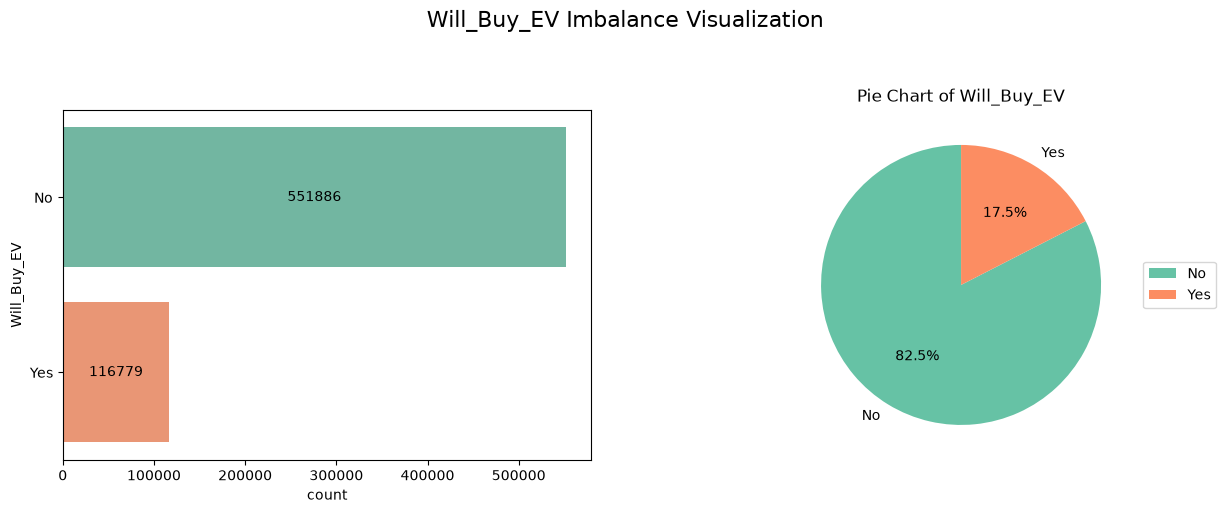

In [14]:
check_class_imbalance(train_df)